<a href="https://colab.research.google.com/github/tanmaybardia/clownizer/blob/main/clownizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [133]:
# you need mediapipe and opencv2 for this
!pip install mediapipe
!wget -q -O detector.tflite -q https://storage.googleapis.com/mediapipe-models/face_detector/blaze_face_short_range/float16/1/blaze_face_short_range.tflite
#this downloads a model for face detection

In [134]:
import cv2
import mediapipe as mp
import numpy as np
import math
import os
from typing import Tuple, Union

from mediapipe.tasks import python
from mediapipe.tasks.python import vision

MARGIN = 10  # pixels
ROW_SIZE = 10  # pixels
FONT_SIZE = 1
FONT_THICKNESS = 1
TEXT_COLOR = (255, 0, 0)  # red
def _normalized_to_pixel_coordinates(n_x: float, n_y: float, image_width: int, image_height: int) -> Union[None, Tuple[int, int]]:
  """Converts normalized value pair to pixel coordinates."""

  # Checks if the float value is between 0 and 1
  if (n_x < 0 or n_x > 1 or n_y < 0 or n_y > 1):
    return None
  else:
    x_px = min(math.floor(n_x * image_width), image_width - 1)
    y_px = min(math.floor(n_y * image_height), image_height - 1)
    return x_px, y_px




In [135]:
def visualise(
    image,
    detection_result
) ->np.ndarray:
  annotated_image = image.copy()
  height, width, _ = image.shape

  for detection in detection_result.detections:
    #Draw bounding box
    bbox = detection.bounding_box
    start_point = bbox.origin_x, bbox.origin_y
    end_point = bbox.origin_x + bbox.width, bbox.origin_y + bbox.height
    #cv2.rectangle(annotated_image, start_point, end_point, TEXT_COLOR, 3)

    #draw keypoints
    for keypoint in detection.keypoints:
      keypoint_px = _normalized_to_pixel_coordinates(keypoint.x, keypoint.y, width, height)
      color = (0, 255, 0)
      #cv2.circle(annotated_image, keypoint_px, 2, 2)

    print(detection.keypoints)
  return annotated_image



In [136]:
clownpath="/content/sample_data/vecteezy_bright-clown-wig-with-multicolor-hair-on-transparent-background_55656360.png"
imgpath = "/content/sample_data/ananomonize.jpeg"

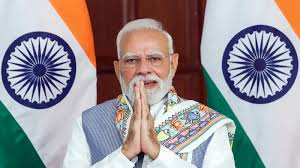

In [137]:
from google.colab.patches import cv2_imshow
import cv2

#read img
img = cv2.imread(imgpath)

if img is None:
    print(f"Error: Could not load image from {imgpath}. Please check if the file exists and is accessible.")
else:
    cv2_imshow(img)

[NormalizedKeypoint(x=0.438051700592041, y=0.3775671422481537, label=None, score=0.0), NormalizedKeypoint(x=0.5102531313896179, y=0.37839844822883606, label=None, score=0.0), NormalizedKeypoint(x=0.46986520290374756, y=0.45842400193214417, label=None, score=0.0), NormalizedKeypoint(x=0.4714711308479309, y=0.5100914239883423, label=None, score=0.0), NormalizedKeypoint(x=0.4051128625869751, y=0.3869340717792511, label=None, score=0.0), NormalizedKeypoint(x=0.5590829253196716, y=0.3898206651210785, label=None, score=0.0)]


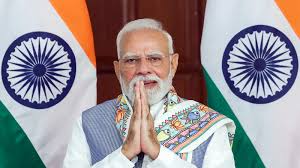

In [138]:
base = python.BaseOptions(model_asset_path = 'detector.tflite')
options = vision.FaceDetectorOptions(base_options=base)
detector = vision.FaceDetector.create_from_options(options)

image = mp.Image.create_from_file(imgpath)
detection_result = detector.detect(image)

image_copy = np.copy(image.numpy_view())
annotated_image = visualise(image_copy, detection_result)

rgb_anno = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)
cv2_imshow(rgb_anno)

The `FaceDetector` model typically outputs 6 keypoints in the following order:

*   **0**: Right eye
*   **1**: Left eye
*   **2**: Nose tip
*   **3**: Mouth center
*   **4**: Right ear tragion
*   **5**: Left ear tragion

Let's print these out explicitly.

In [139]:
# Assuming there's at least one face detected
if detection_result.detections:
    first_face_detection = detection_result.detections[0]
    keypoints = first_face_detection.keypoints

    keypoint_names = [
        "Right eye",
        "Left eye",
        "Nose tip",
        "Mouth center",
        "Right ear tragion",
        "Left ear tragion"
    ]

    print("Facial Keypoints:")
    for i, keypoint in enumerate(keypoints):
        print(f"  {keypoint_names[i]}: (x={keypoint.x:.4f}, y={keypoint.y:.4f})")
else:

    print("No faces detected.")

Facial Keypoints:
  Right eye: (x=0.4381, y=0.3776)
  Left eye: (x=0.5103, y=0.3784)
  Nose tip: (x=0.4699, y=0.4584)
  Mouth center: (x=0.4715, y=0.5101)
  Right ear tragion: (x=0.4051, y=0.3869)
  Left ear tragion: (x=0.5591, y=0.3898)


In [140]:
if detection_result.detections:
    bbox = detection_result.detections[0].bounding_box
    radius_nose = int(bbox.width / 6)




(140, 77)


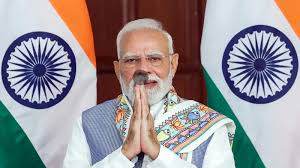

In [141]:
nose_px = detection_result.detections[0].keypoints[2]
height, width, _ = annotated_image.shape # Get height and width from annotated_image
nose_px = _normalized_to_pixel_coordinates(nose_px.x, nose_px.y, width, height)
print(nose_px)

overlay = annotated_image.copy()
alpha = 0.4
beta = 1- alpha
gamma =0

cv2.circle(overlay, (int(nose_px[0]), int(nose_px[1])), int(radius_nose*1.1),(0,0,0),thickness = -1)
output = cv2.addWeighted(overlay, alpha, image_copy, beta, gamma)
rgb_output = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)
cv2_imshow(rgb_output)

# Ensure nose_px is not None before drawing the circles for the gradient

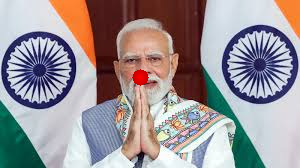

In [142]:
if nose_px:

  start_color = (200,0,0)
  end_color = (255, 0, 0)


  for r in range(radius_nose, 0, -1):
    # Calculate interpolation factor (0 for outer edge, 1 for center)
    interpolation_factor = 1 - (r / radius_nose)

    # Interpolate colors for each channel (RGB)
    current_color = (
        int(start_color[0] * (1 - interpolation_factor) + end_color[0] * interpolation_factor),
        int(start_color[1] * (1 - interpolation_factor) + end_color[1] * interpolation_factor),
        int(start_color[2] * (1 - interpolation_factor) + end_color[2] * interpolation_factor)
    )
    # Draw concentric circles from outside in
    cv2.circle(output, nose_px, r, current_color, thickness = -1)

# Convert the annotated_image from RGB to BGR for correct display with cv2_imshow
display_image_bgr = cv2.cvtColor(output, cv2.COLOR_RGB2BGR)
cv2_imshow(display_image_bgr)

In [143]:
def overlay_transparent(background_img, img_to_overlay_t, x, y):
    """
    Overlays a transparent PNG image onto a background image.
    Handles out-of-bounds coordinates safely by clipping.

    Args:
        background_img (numpy.ndarray): The background image (3-channel BGR).
        img_to_overlay_t (numpy.ndarray): The image with transparency to overlay (4-channel BGRA).
        x (int): The x-coordinate (left edge) where the overlay should start.
        y (int): The y-coordinate (top edge) where the overlay should start.

    Returns:
        numpy.ndarray: The background image with the overlay applied.
    """
    bg_h, bg_w, _ = background_img.shape
    ov_h, ov_w, _ = img_to_overlay_t.shape

    # Calculate the boundaries of the overlay within the background image
    y1, y2 = max(0, y), min(bg_h, y + ov_h)
    x1, x2 = max(0, x), min(bg_w, x + ov_w)

    # Calculate the boundaries of the overlay image that are actually visible
    # These offsets are used to slice the img_to_overlay_t
    y1_ov = max(0, -y)
    y2_ov = min(ov_h, bg_h - y)
    x1_ov = max(0, -x)
    x2_ov = min(ov_w, bg_w - x)

    # If no overlap, return original background
    if x2 <= x1 or y2 <= y1:
        return background_img

    # Extract the region of interest from the background
    roi = background_img[y1:y2, x1:x2]

    # Extract the corresponding part of the overlay image and its alpha channel
    overlay_rgb = img_to_overlay_t[y1_ov:y2_ov, x1_ov:x2_ov, :3]
    alpha_channel = img_to_overlay_t[y1_ov:y2_ov, x1_ov:x2_ov, 3] / 255.0

    # Create inverted alpha mask
    alpha_inv = 1.0 - alpha_channel

    # Convert roi to float for blending calculations
    roi = roi.astype(np.float32)

    # Perform blending for each color channel
    for c in range(0, 3):
        roi[:, :, c] = roi[:, :, c] * alpha_inv + overlay_rgb[:, :, c] * alpha_channel

    # Convert back to uint8 and place it in the background
    background_img[y1:y2, x1:x2] = roi.astype(np.uint8)

    return background_img

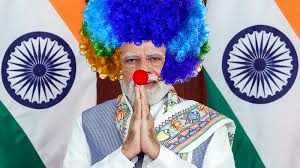

In [144]:
# 1. Load the clown hair PNG with the transparency channel intact!
# Make sure to upload this file to your Colab workspace.
hair_img = cv2.imread(clownpath, cv2.IMREAD_UNCHANGED)

if detection_result.detections:
    bbox = detection_result.detections[0].bounding_box

    # 2. Resize the hair to fit the face
    # Let's make the hair 2x wider than the face
    hair_width = int(bbox.width * 3)

    # Calculate the new height to maintain the aspect ratio of the original PNG
    aspect_ratio = hair_img.shape[0] / hair_img.shape[1]
    hair_height = int(hair_width * aspect_ratio)

    # Resize the transparent image
    resized_hair = cv2.resize(hair_img, (hair_width, hair_height))

    # 3. Calculate where to place it
    # We want to center the hair horizontally over the face
    center_x = int(bbox.origin_x + (bbox.width / 2))
    top_y = int(bbox.origin_y)

    # Offset x so the center of the hair aligns with the center of the face
    paste_x = int(center_x - (hair_width / 2))

    # Offset y so the hair sits on top of the head (adjust the 1.0 to move it up or down)
    paste_y = int(top_y - (hair_height * 0.6))

    # Ensure coordinates don't go negative for paste_x to avoid issues, but allow paste_y to be negative
    paste_x = max(0, paste_x)
    # paste_y = max(0, paste_y) # Removed this line to allow negative paste_y

    # 4. Apply the overlay to your output image
    output = overlay_transparent(output, resized_hair, paste_x, paste_y)

# Convert and display as usual
display_image_bgr = cv2.cvtColor(output, cv2.COLOR_RGB2BGR)
cv2_imshow(display_image_bgr)